# Auto MPG – Feature Engineering and Linear Regression
## 1. Introduction

The main objective of this project is to perform feature engineering and build linear regression models to predict a car's fuel efficiency (mpg) based on its technical specifications. The independent variables are selected using two approaches:

* Forward Selection (custom implementation)
* Backward Selection (custom implementation)

The performance of the resulting models will then be compared, followed by an analysis and interpretation of the obtained results.


## 2. Brief Description of the Dataset
The analysis uses the Auto MPG dataset from the UCI Machine Learning Repository. The dataset contains information about cars and their fuel efficiency. It consists of 398 observations and 7 explanatory variables, with mpg as the target variable.

The dataset includes the following car characteristics:

* mpg – fuel efficiency measured in miles per gallon; this is the dependent variable in the regression models
* cylinders – number of engine cylinders
* displacement – engine displacement
* horsepower – engine horsepower
* weight – vehicle weight
* acceleration – acceleration performance
* model_year – year of manufacture
* origin – origin of the car


## 3. Libraries

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.colormaps()
cmap = plt.get_cmap("Pastel1")

from scipy.stats import norm
from scipy.stats import f_oneway

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.tools.tools import add_constant

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [2]:
!pip install git+https://github.com/kingagla/tukey_with_groups

  Cloning https://github.com/kingagla/tukey_with_groups to c:\users\user\appdata\local\temp\pip-req-build-sjpgazy6
  Resolved https://github.com/kingagla/tukey_with_groups to commit f1c429af8089329f646f0d003115ccdee0237251
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
    Preparing wheel metadata: started
    Preparing wheel metadata: finished with status 'done'


  Running command git clone -q https://github.com/kingagla/tukey_with_groups 'C:\Users\User\AppData\Local\Temp\pip-req-build-sjpgazy6'


## 4. Data upload

In [27]:
columns = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year",
    "origin", "car_name"
]

df = pd.read_csv("auto-mpg.data",sep=r"\s+",names=columns,na_values="?")

In [28]:
with open("auto-mpg.names", "r") as file:
    print(file.read())

1. Title: Auto-Mpg Data

2. Sources:
   (a) Origin:  This dataset was taken from the StatLib library which is
                maintained at Carnegie Mellon University. The dataset was 
                used in the 1983 American Statistical Association Exposition.
   (c) Date: July 7, 1993

3. Past Usage:
    -  See 2b (above)
    -  Quinlan,R. (1993). Combining Instance-Based and Model-Based Learning.
       In Proceedings on the Tenth International Conference of Machine 
       Learning, 236-243, University of Massachusetts, Amherst. Morgan
       Kaufmann.

4. Relevant Information:

   This dataset is a slightly modified version of the dataset provided in
   the StatLib library.  In line with the use by Ross Quinlan (1993) in
   predicting the attribute "mpg", 8 of the original instances were removed 
   because they had unknown values for the "mpg" attribute.  The original 
   dataset is available in the file "auto-mpg.data-original".

   "The data concerns city-cycle fuel consumptio

## 5. Descriptive statistics

In [29]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [30]:
#statistical summary of numerical columns in seasons_stats - numerical variables

df_desc_numerical = df.describe()
df_desc_numerical = df_desc_numerical.drop(columns = ['origin'], inplace = False)
df_desc_numerical.loc['skewness'] = round(df_desc_numerical.skew(numeric_only = True), 2)
df_desc_numerical.loc['kurtosis'] = round(df_desc_numerical.kurt(numeric_only = True), 2)
df_desc_numerical

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000
skewness,2.780000,2.830000,0.850000,1.710000,0.410000,2.820000,2.550000
kurtosis,8.720000,8.990000,-0.470000,2.770000,-0.350000,8.920000,7.280000


In [31]:
#statistical summary of categorical columns in seasons_stats - categorical variables

df_desc_categorical = df[['car_name', 'origin']].copy()
df_desc_categorical['origin'] = df_desc_categorical['origin'].astype('category')
df_desc_categorical = df_desc_categorical.describe()
df_desc_categorical

,car_name,origin
count,398,398
unique,305,3
top,ford pinto,1
freq,6,249


### origin - categorical variables

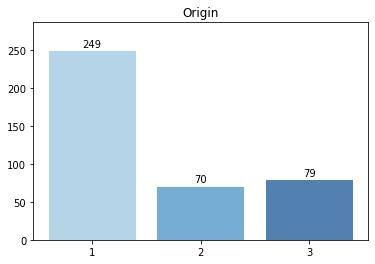

In [32]:
origin_bar = df['origin'].value_counts().sort_index()
origin_bar

colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(origin_bar)))

bars = plt.bar(origin_bar.index, origin_bar.values, color = colors_bar, alpha = 0.7)

plt.xticks(origin_bar.index)
plt.ylim(0, max(origin_bar.values) * 1.15)
plt.bar_label(bars, fontsize = 10, padding = 2)
plt.title("Origin");

### car_name - categorical variables

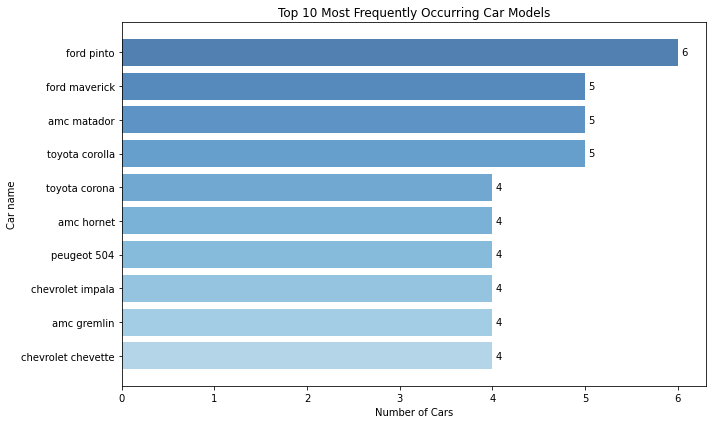

In [33]:
car_name_bar = df['car_name'].value_counts().head(10).sort_values()

plt.figure(figsize=(10,6))
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(car_name_bar)))

bars = plt.barh(car_name_bar.index, car_name_bar.values, color = colors_bar, alpha = 0.7)

plt.bar_label(bars, fontsize = 10, padding = 3)
plt.xlabel('Number of Cars')
plt.ylabel('Car name')
plt.title('Top 10 Most Frequently Occurring Car Models')

plt.tight_layout()
plt.show()

### Comment:
The dataset contains 398 observations and 8 variables, including the target variable mpg. Most variables are numerical, while origin and car_name are categorical variables. origin represents the origin of the car, while car_name represents the car model name.


In [34]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [35]:
(df.isna().mean()*100).round(2)

mpg             0.00
cylinders       0.00
displacement    0.00
horsepower      1.51
weight          0.00
acceleration    0.00
model_year      0.00
origin          0.00
car_name        0.00
dtype: float64

In [36]:
df[df["horsepower"].isna() == True]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
32,25.0,4,98.0,NaN,2046.0,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875.0,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835.0,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905.0,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320.0,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035.0,20.5,82,1,amc concord dl


### Comment:

There are 6 missing values for the horsepower variable.

## 6. Relationship Between Variables

In [37]:
# I exclude the origin variable from the correlation analysis.
df_corr = df.drop(columns = ['origin'])
numeric_df = df_corr.select_dtypes(include="number")
numeric_df.corr()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137
model_year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000


In [38]:
df['cylinders'].unique()

array([8, 4, 6, 3, 5], dtype=int64)

In [39]:
# ANOVA
# H0: The mean mpg is the same across all cylinder groups.
# H1: At least one group has a different mean mpg.

groups = [
    group["mpg"].values
    for _, group in df.groupby("cylinders")
]

stat, p_value = f_oneway(*groups)
alpha = 0.05

print("F-statistic:", stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Reject H0 - the mean mpg differs between groups.")
else:
    print("Fail to reject H0 - there is insufficient evidence of differences between groups.")

F-statistic: 172.5917853028911
p-value: 3.679939295400561e-85
Reject H0 - the mean mpg differs between groups.


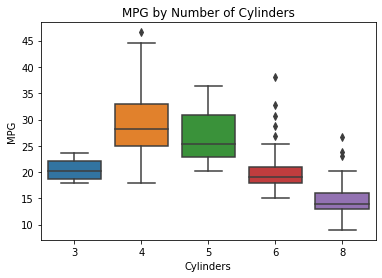

In [40]:
sns.boxplot(data=df, x="cylinders", y="mpg")
plt.title("MPG by Number of Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("MPG")
plt.show()

In [41]:
tukey = pairwise_tukeyhsd(endog=df["mpg"],groups=df["cylinders"],alpha=0.05)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     3      4   8.7368 0.0027   2.1903  15.2832   True
     3      5   6.8167 0.3264  -3.0866  16.7199  False
     3      6  -0.5643 0.9993     -7.2   6.0715  False
     3      8  -5.5869 0.1416 -12.1948    1.021  False
     4      5  -1.9201 0.9569  -9.4611   5.6209  False
     4      6  -9.3011    0.0  -10.982  -7.6201   True
     4      8 -14.3237    0.0  -15.891 -12.7564   True
     5      6   -7.381 0.0627 -14.9996   0.2377  False
     5      8 -12.4036 0.0001 -19.9979  -4.8092   True
     6      8  -5.0226    0.0  -6.9289  -3.1164   True
------------------------------------------------------


### Comment:

The Tukey HSD test revealed statistically significant differences in mean MPG between the 3–4, 4–6, 4–8, 5–8, and 6–8 cylinder groups. No statistically significant differences were found between the remaining pairs. The largest difference occurs between the 4- and 8-cylinder groups, with a mean MPG difference of approximately 14.32.

In [42]:
df["origin"].value_counts()

1    249
3     79
2     70
Name: origin, dtype: int64

In [43]:
groups = [
    group["mpg"].values
    for _, group in df.groupby("origin")
]

f_stat, p_value = f_oneway(*groups)
alpha = 0.05

print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Reject H0 - there are statistically significant differences between the groups.")
else:
    print("Fail to reject H0 - there is insufficient evidence of differences between the groups.")

F-statistic: 98.54179491075871
p-value: 1.9154864184128e-35
Reject H0 - there are statistically significant differences between the groups.


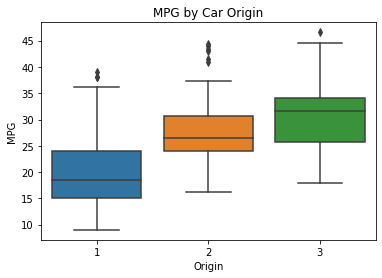

In [44]:
sns.boxplot(data=df, x="origin", y="mpg")
plt.title("MPG by Car Origin")
plt.xlabel("Origin")
plt.ylabel("MPG")
plt.show()


In [45]:
tukey = pairwise_tukeyhsd(endog=df["mpg"], groups=df["origin"], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     1      2   7.8079    0.0  5.771  9.8448   True
     1      3  10.3671    0.0 8.4228 12.3114   True
     2      3   2.5592 0.0404 0.0877  5.0307   True
---------------------------------------------------


### Comment: 

There are statistically significant differences in mean fuel efficiency (mpg) between cars from different origin groups. The Tukey HSD test revealed significant differences in mean mpg between all origin groups. The largest difference occurs between groups 1 and 3, amounting to approximately 10.37 MPG.

In [46]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'car_name'],
      dtype='object')

## 7. Correlation Analysis of the Original Data

              cylinders  displacement  horsepower    weight  acceleration  \
cylinders      1.000000      0.950721    0.842983  0.896017     -0.505419   
displacement   0.950721      1.000000    0.897257  0.932824     -0.543684   
horsepower     0.842983      0.897257    1.000000  0.864538     -0.689196   
weight         0.896017      0.932824    0.864538  1.000000     -0.417457   
acceleration  -0.505419     -0.543684   -0.689196 -0.417457      1.000000   
model_year    -0.348746     -0.370164   -0.416361 -0.306564      0.288137   

              model_year  
cylinders      -0.348746  
displacement   -0.370164  
horsepower     -0.416361  
weight         -0.306564  
acceleration    0.288137  
model_year      1.000000  


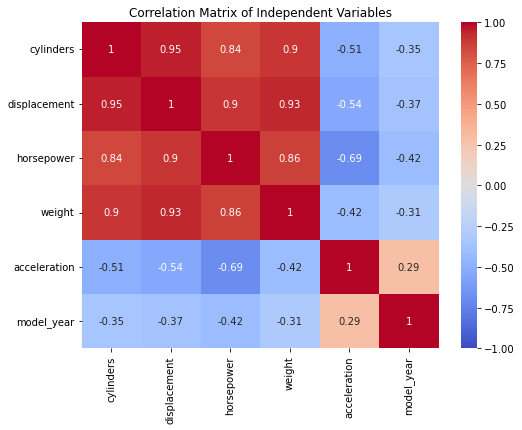

In [47]:
X = df[[
    "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year"
]]

corr = X.corr()

print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Independent Variables")
plt.show()

## 8. Feature engineering

###  a. Handling Missing Data

In [48]:
(df.isna().mean()*100).round(2)

mpg             0.00
cylinders       0.00
displacement    0.00
horsepower      1.51
weight          0.00
acceleration    0.00
model_year      0.00
origin          0.00
car_name        0.00
dtype: float64

In [49]:
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].mean())

In [50]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

###  b. Data Encoding

In [51]:
df = pd.get_dummies(df, columns = ['origin'], drop_first = True)

### Comment:
The origin variable was encoded using One-Hot Encoding because it contains the values 1, 2, and 3. Treating these values as numerical variables could incorrectly imply an ordinal relationship, such as 1 < 2 < 3.

### c. Creating New Variables

In [52]:
df["hp_per_cylinder"] = df["horsepower"] / df["cylinders"]
df["weight_per_displacement"] = df["weight"] / df["displacement"]
#df["acceleration_per_weight"] = df["acceleration"] / df["weight"]
df  = df.drop(columns = ['horsepower','cylinders','weight','displacement'])

In [53]:
df.columns

Index(['mpg', 'acceleration', 'model_year', 'car_name', 'origin_2', 'origin_3',
       'hp_per_cylinder', 'weight_per_displacement'],
      dtype='object')

In [54]:
features = [
    "acceleration","model_year","hp_per_cylinder","weight_per_displacement"]

X = df[features]
y = df["mpg"]

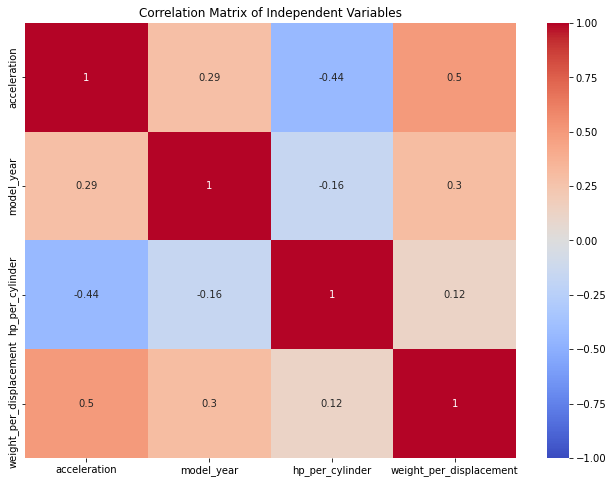

In [55]:
corr = X.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Independent Variables")
plt.show()

In [56]:
corr

,acceleration,model_year,hp_per_cylinder,weight_per_displacement
acceleration,1.000000,0.288137,-0.436235,0.496180
model_year,0.288137,1.000000,-0.158954,0.304517
hp_per_cylinder,-0.436235,-0.158954,1.000000,0.122418
weight_per_displacement,0.496180,0.304517,0.122418,1.000000


### Comment:
Two additional variables were created:
* hp_per_cylinder – the ratio of horsepower to the number of cylinders
* weight_per_displacement – the ratio of vehicle weight to engine displacement

The highest absolute correlation was observed between acceleration and weight_per_displacement (r = 0.496), while the correlation between acceleration and hp_per_cylinder was r = -0.436.

This indicates that there is no strong correlation between the analyzed independent variables. Therefore, there is no basis for removing any of these variables solely based on their correlation values.

In the next stage, the impact of individual variables on the quality of the linear regression model will be examined, along with an additional multicollinearity analysis using VIF.

### Preliminary Multicollinearity Analysis Using VIF

In [57]:
Xvar = df.drop(columns=["mpg", "car_name"])

Xvif = add_constant(Xvar.astype(float))

vif = pd.DataFrame({
    "features": Xvar.columns,
    "VIF Factor": [
        variance_inflation_factor(Xvif.values, i)
        for i in range(1, Xvif.shape[1])
    ]
})

vif

,features,VIF Factor
0,acceleration,2.130123
1,model_year,1.202559
2,origin_2,1.887647
3,origin_3,1.921351
4,hp_per_cylinder,1.603519
5,weight_per_displacement,3.520584


### Comment:

The VIF analysis did not reveal any significant multicollinearity among the independent variables. All VIF values are relatively low and do not exceed the accepted threshold of 10.

The highest VIF was observed for weight_per_displacement (VIF = 3.52), which does not indicate strong multicollinearity. The next highest values were obtained for acceleration (2.13), origin_3 (1.92), and origin_2 (1.89). The lowest VIF value was observed for model_year (1.20), indicating very little dependence on the other variables.

Based on the analysis, there is no need to remove any variables solely due to multicollinearity. All analyzed features can be included in further linear regression modeling.

### d. Feature Selection - Forward_selection

In [58]:
def forward_selection(df, y_name='mpg', tolerance=0.01):
    attr_names = list(df.drop([y_name, 'car_name'], axis=1).columns)
    all_possible = attr_names.copy()

    model = LinearRegression()

    current_names = []
    last_score = 0
    cur_diff = 1

    while current_names != all_possible and cur_diff > tolerance:
        scores = []

        for name in attr_names:
            columns = current_names + [name]

            model.fit(df[columns], df[y_name])
            score = model.score(df[columns], df[y_name])

            scores.append((name, score))

        best = np.argmax([score for _, score in scores])
        chosen_col, best_score = scores[best]

        current_names.append(chosen_col)
        cur_diff = best_score - last_score

        attr_names.remove(chosen_col)
        last_score = best_score

        print(scores)
        print("Chosen columns:", chosen_col, best_score)
        print("Current features:", current_names)
        print()

    return current_names

In [59]:
selected_features = forward_selection(df)

print(selected_features)

[('acceleration', 0.17664276963558911), ('model_year', 0.335550411470557), ('origin_2', 0.06709248260293132), ('origin_3', 0.19551825117501476), ('hp_per_cylinder', 0.041769175497401334), ('weight_per_displacement', 0.4847231273833369)]
Chosen columns: weight_per_displacement 0.4847231273833369
Current features: ['weight_per_displacement']

[('acceleration', 0.49215307124730334), ('model_year', 0.6333859777953089), ('origin_2', 0.4879071808822526), ('origin_3', 0.5041375479175537), ('hp_per_cylinder', 0.569870317477054)]
Chosen columns: model_year 0.6333859777953089
Current features: ['weight_per_displacement', 'model_year']

[('acceleration', 0.633897474910601), ('origin_2', 0.6336456785971833), ('origin_3', 0.6466192020895649), ('hp_per_cylinder', 0.6802494634445042)]
Chosen columns: hp_per_cylinder 0.6802494634445042
Current features: ['weight_per_displacement', 'model_year', 'hp_per_cylinder']

[('acceleration', 0.694605299759463), ('origin_2', 0.6802623288446024), ('origin_3', 0.6

In [60]:
model_forward = LinearRegression()

X_forward = df[selected_features]
y = df["mpg"]

model_forward.fit(X_forward, y)
r2_forward = model_forward.score(X_forward, y)
y_pred_forward = model_forward.predict(X_forward)

print("R^2:", r2_forward)

R^2: 0.7035501013148107


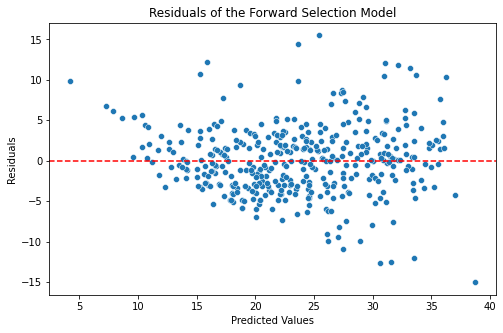

In [61]:
residuals = y - y_pred_forward

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_forward, y=residuals)

plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals of the Forward Selection Model")
plt.show()

### Comment:

Using the Forward Selection method, the model selected the variables weight_per_displacement, model_year, hp_per_cylinder, acceleration, and origin_3. Based on these variables, a linear regression model was built to predict mpg. The model achieved an R² of 0.703, meaning that approximately 70.3% of the variability in mpg is explained by the model.

In the residual plot, most residuals are centered around zero. However, the spread of the residuals increases for higher predicted values. Therefore, the model does not perfectly satisfy the assumption of constant residual variance (homoscedasticity).

### e. Feature Selection - Backward_selection

In [62]:
def backward_selection(df, y_name='mpg', tolerance=0.01):
    attr_names = list(df.drop([y_name, 'car_name'], axis=1).columns)

    model = LinearRegression()

    current_names = attr_names.copy()

    model.fit(df[current_names], df[y_name])
    last_score = model.score(df[current_names], df[y_name])
    print(f"Including_all: {last_score}")
    cur_diff = 1

    while len(current_names) > 1 and cur_diff > tolerance:
        scores = []

        for name in current_names:
            columns = current_names.copy()
            columns.remove(name)

            model.fit(df[columns], df[y_name])
            score = model.score(df[columns], df[y_name])

            scores.append((name, score))
            print(f"Names score: {name} {score}")

        best = np.argmax([score for _, score in scores])
        removed_col, best_score = scores[best]

        cur_diff = last_score - best_score

        if cur_diff >= tolerance:
            break

        current_names.remove(removed_col)
        last_score = best_score

        print(scores)
        print("Removed column:", removed_col, best_score)
        print("Current features:", current_names)
        print("R2 difference:", cur_diff)
        print()

    return current_names

In [63]:
selected_features_backward = backward_selection(df)

model_backward = LinearRegression()

X_backward = df[selected_features_backward]
y = df["mpg"]

model_backward.fit(X_backward, y)

r2_backward = model_backward.score(X_backward, y)
y_pred_backward = model_backward.predict(X_backward)

print("Selected Features:", selected_features_backward)
print("R^2:", r2_backward)

Including_all: 0.7076856254115799
Names score: acceleration 0.7000798280852691
Names score: model_year 0.5943861661556991
Names score: origin_2 0.7035501013148109
Names score: origin_3 0.694605463663666
Names score: hp_per_cylinder 0.6579979057114631
Names score: weight_per_displacement 0.6154717152789243
[('acceleration', 0.7000798280852691), ('model_year', 0.5943861661556991), ('origin_2', 0.7035501013148109), ('origin_3', 0.694605463663666), ('hp_per_cylinder', 0.6579979057114631), ('weight_per_displacement', 0.6154717152789243)]
Removed column: origin_2 0.7035501013148109
Current features: ['acceleration', 'model_year', 'origin_3', 'hp_per_cylinder', 'weight_per_displacement']
R2 difference: 0.004135524096768983

Selected Features: ['acceleration', 'model_year', 'origin_3', 'hp_per_cylinder', 'weight_per_displacement']
R^2: 0.7035501013148109


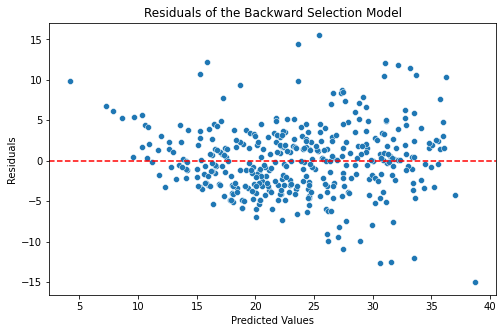

In [64]:
residuals = y - y_pred_backward

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_backward, y=residuals)

plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals of the Backward Selection Model")
plt.show()

## 9. Comparison of the Two Models

In [65]:
r2_forward = model_forward.score(X_forward, y)
rmse_forward = np.sqrt(mean_squared_error(y, y_pred_forward))
mae_forward = mean_absolute_error(y, y_pred_forward)

r2_backward = model_backward.score(X_backward, y)
rmse_backward = np.sqrt(mean_squared_error(y, y_pred_backward))
mae_backward = mean_absolute_error(y, y_pred_backward)

results = pd.DataFrame({
    "Model": ["Forward", "Backward"],
    "R2": [r2_forward, r2_backward],
    "RMSE": [rmse_forward, rmse_backward],
    "MAE": [mae_forward, mae_backward]
})

print(results)

      Model       R2      RMSE       MAE
0   Forward  0.70355  4.250236  3.230426
1  Backward  0.70355  4.250236  3.230426


### Comment:

Both the Forward and Backward models achieved identical results: R² = 0.704, RMSE = 4.25, and MAE = 3.23. This means that the models explain approximately 70.4% of the variability in MPG, with an average prediction error of about 3.23 MPG. The identical results indicate that both feature selection methods selected the same or an equivalent set of variables.